# Module 3: Continuous Time Random Walk

This module studies a random walk whose jumps occur at random times. In a discrete time random walk, the position changes at the deterministic times

$$
n=1,2,3,\ldots
$$

Let

$$
S_n=\sum_{i=1}^{n}Z_i
$$

be a discrete time random walk. In a continuous time random walk, the position changes at the event times of a Poisson process:

$$
X(t)=S_{N(t)}.
$$

Here:

- $S_n$ is the position after $n$ jumps;
- $N(t)$ is the number of Poisson events by time $t$;
- $X(t)$ is the position of the walk at time $t$.

The Poisson process controls **when** jumps happen. The random walk steps control **where** the process moves.

## Libraries

Run the cell below to import the libraries used in this module.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, binom

In [2]:
FIGSIZE = (8, 4.5)
SMALL_FIGSIZE = (8, 3.5)
SUBPLOT_FIGSIZE = (8, 9)

HIST_ALPHA = 0.65
OVERLAP_ALPHA = 0.45

plt.rcParams["figure.figsize"] = FIGSIZE
plt.rcParams["axes.grid"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["legend.frameon"] = False

plt.rcParams["lines.markersize"] = 4

## Example 1: Sample paths

We construct the process from two parts. First, let $N(t)$ be a Poisson process with rate $\lambda$, so that $N(t)$ counts how many jump times have occurred before time $t$. Second, let $Z_1,Z_2,\ldots$ be independent jump directions with

$$
\mathbb{P}(Z_i=1)=p, \qquad \mathbb{P}(Z_i=-1)=1-p.
$$

The continuous time random walk is

$$
X(t)=\sum_{i=1}^{N(t)} Z_i.
$$

To simulate the path, we generate exponential waiting times

$$
U_k\sim \mathrm{Exp}(\lambda).
$$

The jump times are

$$
T_k=U_1+\cdots+U_k.
$$

At each jump time, the position changes by $+1$ or $-1$. Between two jump times, the position stays constant, so the path is drawn as a step function.

In [3]:
def simulate_ctrw(T, lambda_rate, p, rng):
    """
    Simulate one continuous time random walk path.

    Parameters
    ----------
    T : float
        Final time.
    lambda_rate : float
        Jump rate of the Poisson process.
    p : float
        Probability of an upward jump.
    rng : numpy.random.Generator
        Random number generator.

    Returns
    -------
    times : numpy array
        Time points used for plotting.
    X : numpy array
        Position values at the time points.
    n_jumps : int
        Number of jumps before time T.
    """

    # Store the jump times
    jump_times = []

    # Start at time 0
    current_time = 0

    # Generate exponential waiting times until we pass T
    while current_time < T:
        waiting_time = rng.exponential(1 / lambda_rate)
        current_time = current_time + waiting_time

        if current_time <= T:
            jump_times.append(current_time)

    # Number of jumps before time T
    n_jumps = len(jump_times)

    # Generate jump directions
    jumps = rng.choice([1, -1], size=n_jumps, p=[p, 1 - p])

    # Compute positions after the jumps
    positions = np.cumsum(jumps)

    # Add time 0 and final time T
    times = np.concatenate(([0], jump_times, [T]))

    # Add initial position and final constant position
    if n_jumps > 0:
        X = np.concatenate(([0], positions, [positions[-1]]))
    else:
        X = np.array([0, 0])

    return times, X, n_jumps

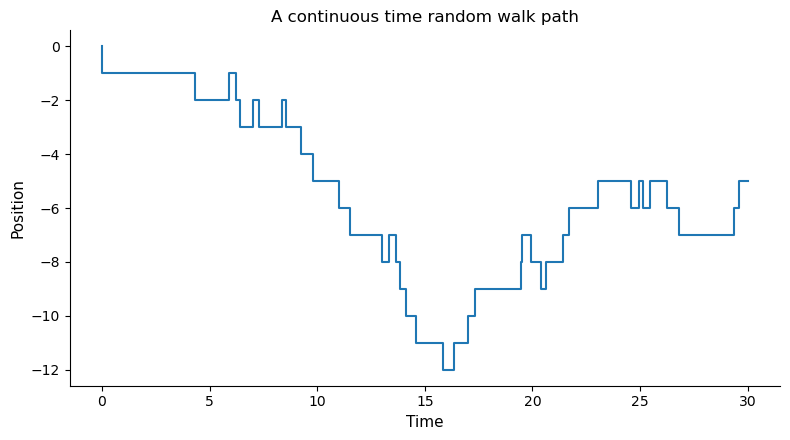

number of jumps: 39
final position: -5


In [4]:
# Time horizon
T = 30

# Jump rate
lambda_rate = 1.0

# Probability of jumping upward
p = 0.5

# Create a random generator
rng = np.random.default_rng()

# Simulate one path
times, X, n_jumps = simulate_ctrw(T, lambda_rate, p, rng)

# Plot one path
plt.figure(figsize=FIGSIZE)

plt.step(times, X, where="post")

plt.xlabel("Time")
plt.ylabel("Position")
plt.title("A continuous time random walk path")
plt.tight_layout()
plt.show()

print("number of jumps:", n_jumps)
print("final position:", X[-1])

The simulated path is flat between consecutive jump times and changes only when a Poisson event occurs. The printed value `number of jumps` is the realized value of $N(T)$, while `final position` is the realized value of $X(T)$. This separates the random timing of the jumps from their random directions.

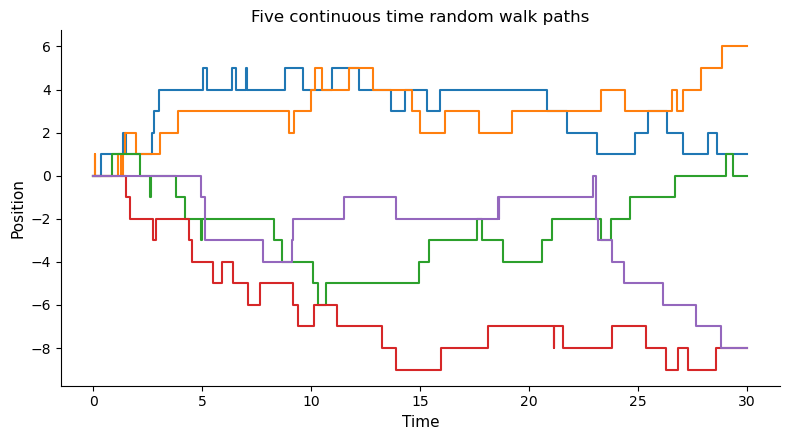

In [5]:
# Number of sample paths
n_paths = 5

# Create a random generator
rng = np.random.default_rng()

plt.figure(figsize=FIGSIZE)

for path in range(n_paths):
    times, X, n_jumps = simulate_ctrw(T, lambda_rate, p, rng)
    plt.step(times, X, where="post")

plt.xlabel("Time")
plt.ylabel("Position")
plt.title("Five continuous time random walk paths")
plt.tight_layout()
plt.show()

The five paths follow the same model but have different jump times and directions. Unlike the discrete time random walk, the number of jumps before time $T$ is also random.

## Example 2: Effect of the jump rate $\lambda$

Now we keep the jump probability $p$ fixed and change the jump rate $\lambda$. For a fixed time $T$,

$$
\mathbb{E}[N(T)] = \lambda T.
$$

Since each jump has mean $2p-1$, the position satisfies

$$
\mathbb{E}[X(T)]=\lambda T(2p-1),
\qquad
\operatorname{Var}(X(T))=\lambda T.
$$

The parameter $\lambda$ controls how often jumps occur. The parameter $p$ controls their direction.

lambda = 0.5, expected jumps = 15.0, realized jumps = 15
lambda = 1.0, expected jumps = 30.0, realized jumps = 43
lambda = 2.0, expected jumps = 60.0, realized jumps = 57


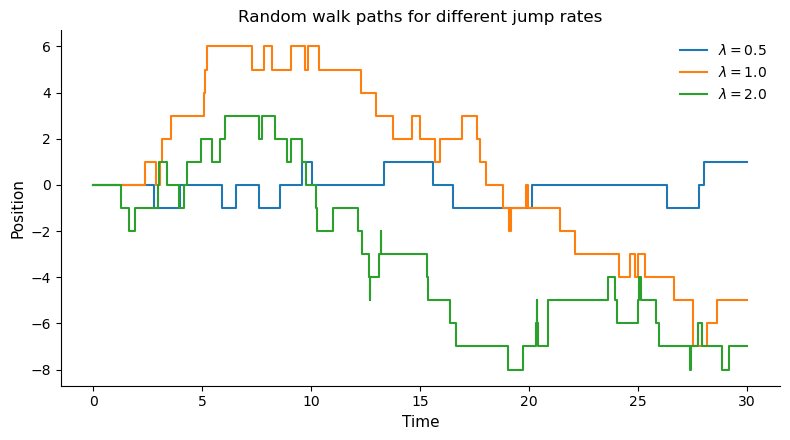

In [6]:
# Time horizon
T = 30

# Probability of jumping upward
p = 0.5

# Different jump rates
lambda_values = [0.5, 1.0, 2.0]

# Create a random generator
rng = np.random.default_rng()

plt.figure(figsize=FIGSIZE)

for lambda_rate in lambda_values:
    # Simulate one path for this value of lambda
    times, X, n_jumps = simulate_ctrw(T, lambda_rate, p, rng)

    # Plot this path
    plt.step(times, X, where="post", label=f"$\\lambda={lambda_rate}$")

    # Print the realized number of jumps
    expected_jumps = lambda_rate * T
    print(f"lambda = {lambda_rate}, expected jumps = {expected_jumps:.1f}, realized jumps = {n_jumps}")

plt.xlabel("Time")
plt.ylabel("Position")
plt.title("Random walk paths for different jump rates")
plt.legend()
plt.tight_layout()
plt.show()

Each curve is one realization for a different value of $\lambda$. A larger rate gives more jumps on average during the same time interval. The printed expected and realized counts make clear that $\lambda T$ is an average, while $N(T)$ remains random.

## Example 3: Distribution of $X(T)$

Now we fix a final time $T$ and repeat the simulation many times. For each simulation, we record only the final position $X(T)$. This changes the question. In Examples 1 and 2, we looked at sample paths. Here we look at a distribution at one fixed time.

In discrete time, the number of steps $n$ is fixed. In continuous time, the number of jumps before time $T$ is random:

$$
N(T)\sim \mathrm{Poisson}(\lambda T).
$$

Therefore,

$$
X(T)=Z_1+\cdots+Z_{N(T)}.
$$

First, we estimate the distribution of $X(T)$ by simulation.

In [7]:
def simulate_ctrw_final(T, lambda_rate, p, rng):
    """
    Simulate only the final value X(T) of a continuous time random walk.
    """

    # Simulate the number of jumps before time T
    n_jumps = rng.poisson(lambda_rate * T)

    # Simulate the number of upward jumps
    n_up = rng.binomial(n_jumps, p)

    # The remaining jumps are downward jumps
    n_down = n_jumps - n_up

    # Final position
    X_T = n_up - n_down

    return X_T

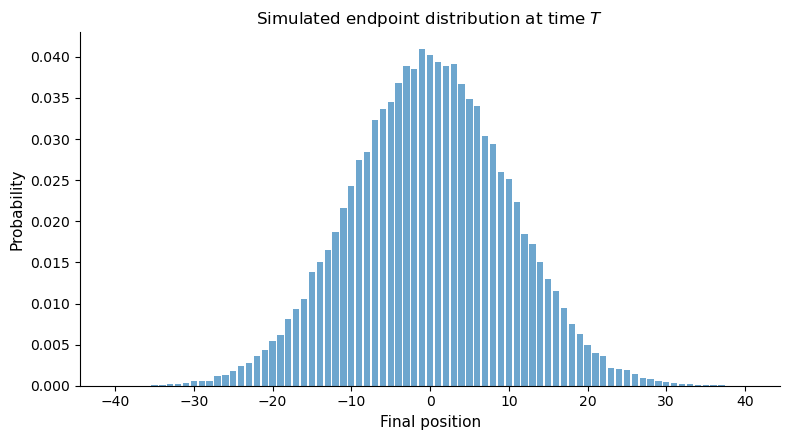

In [8]:
# Time horizon
T = 100

# Jump rate
lambda_rate = 1.0

# Probability of jumping upward
p = 0.5

# Number of repeated simulations
N = 50000

# Create a random generator
rng = np.random.default_rng()

# Simulate final positions
X_final = []

for run in range(N):
    X_T = simulate_ctrw_final(T, lambda_rate, p, rng)
    X_final.append(X_T)

# Convert to numpy array
X_final = np.array(X_final)

# Use a stable plotting range based on the theoretical mean and standard deviation
mean_position = lambda_rate * T * (2 * p - 1)
std_position = np.sqrt(lambda_rate * T)
x_min = int(np.floor(mean_position - 4 * std_position))
x_max = int(np.ceil(mean_position + 4 * std_position))
x_values = np.arange(x_min, x_max + 1)

# Simulated probability for each final position
simulated_probabilities = []

for x in x_values:
    probability = np.mean(X_final == x)
    simulated_probabilities.append(probability)

# Plot the empirical distribution of X(T)
plt.figure(figsize=FIGSIZE)

plt.bar(
    x_values,
    simulated_probabilities,
    width=0.8,
    alpha=HIST_ALPHA
)

plt.xlabel("Final position")
plt.ylabel("Probability")
plt.title("Simulated endpoint distribution at time $T$")
plt.tight_layout()
plt.show()

Each independent simulation gives one value of $X(T)$, and each bar estimates

$$
\mathbb{P}(X(T)=x).
$$

When $p=0.5$, the distribution is centered near $0$. Both even and odd positions can occur because the number of jumps $N(T)$ is random. This differs from a discrete time walk observed after a fixed number of steps.

We can also compare the simulation with the theoretical distribution. First,

$$
N(T)\sim \mathrm{Poisson}(\lambda T).
$$

Given $N(T)=n$, the final position is the endpoint of a discrete time random walk with $n$ steps. Conditioning on the possible values of $N(T)$ gives

$$
\mathbb{P}(X(T)=x)
= \sum_{n=0}^{\infty} \mathbb{P}(N(T)=n)\mathbb{P}(S_n=x).
$$

The infinite sum is exact. The code evaluates it up to a large cutoff, so the omitted Poisson probability is negligible.

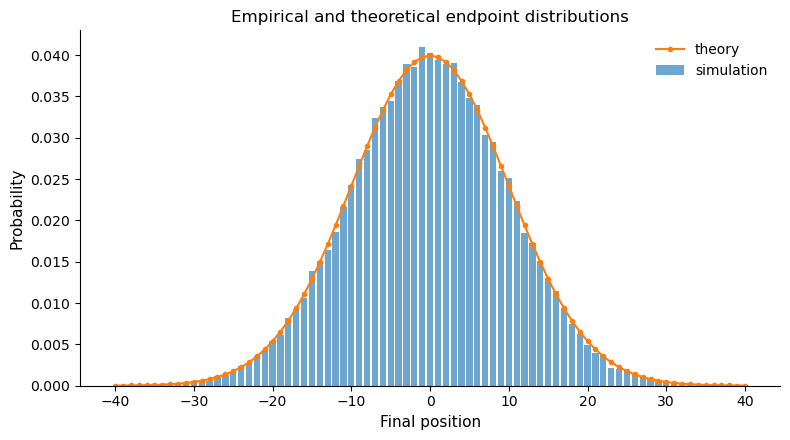

In [9]:
# Reuse the simulated final positions and plotting range from the previous experiment

# Mean number of jumps by time T
mean_jumps = lambda_rate * T

# Use a sufficiently large cutoff for the Poisson sum
n_max = int(poisson.ppf(0.999999, mean_jumps)) + 10

theoretical_probabilities = []

for x in x_values:
    probability = 0

    for n in range(n_max + 1):
        # X(T)=x is possible only if n and x have the same parity
        if abs(x) <= n and (n + x) % 2 == 0:
            # Number of upward jumps needed
            n_up = (n + x) // 2

            # Probability of n jumps by time T
            p_n = poisson.pmf(n, mean_jumps)

            # Probability of ending at x after n jumps
            p_x_given_n = binom.pmf(n_up, n, p)

            probability = probability + p_n * p_x_given_n

    theoretical_probabilities.append(probability)

# Plot empirical and theoretical probabilities
plt.figure(figsize=FIGSIZE)

plt.bar(
    x_values,
    simulated_probabilities,
    width=0.8,
    alpha=HIST_ALPHA,
    label="simulation"
)

plt.plot(
    x_values,
    theoretical_probabilities,
    "o-",
    color="C1",
    markersize=3,
    label="theory"
)

plt.xlabel("Final position")
plt.ylabel("Probability")
plt.title("Empirical and theoretical endpoint distributions")
plt.legend()
plt.tight_layout()
plt.show()

The bars give the empirical probabilities from the same simulated sample used above. The curve gives the theoretical probabilities obtained by conditioning on $N(T)$. Their close agreement checks the simulation and connects the continuous time model with the discrete time endpoint distribution.

## Tasks: Random price changes at transaction times

We can interpret the same model as a simple price change model. Trades occur at random times according to a Poisson process with rate $\lambda$. At each trade, the price increases by $1$ with probability $p$ and decreases by $1$ with probability $1-p$. Then $X(t)$ represents the cumulative price change up to time $t$.

Use simulation to estimate

$$
\mathbb{P}(X(T)>0).
$$

This is the probability that the price is higher at time $T$ than at time $0$.

In [10]:
# Estimate P(X(T) > 0) by simulation.
# You can use simulate_ctrw_final().

In [11]:
# Time horizon
T = 100

# Transaction rate
lambda_rate = 1.0

# Probability that the price moves upward
p = 0.55

# Number of repeated simulations
N = 10000

# Create a random generator
rng = np.random.default_rng()

# Count how many times the final price change is positive
positive_count = 0

for run in range(N):
    X_T = simulate_ctrw_final(T, lambda_rate, p, rng)

    if X_T > 0:
        positive_count = positive_count + 1

# Monte Carlo estimate
probability_positive = positive_count / N

print("estimated P(X(T) > 0):", probability_positive)

estimated P(X(T) > 0): 0.8247


The estimate is a Monte Carlo estimate. It is computed as

$$
\frac{\text{number of simulations with } X(T)>0}{\text{number of simulations}}.
$$

When $p>0.5$, upward jumps are more likely than downward jumps. This gives the process a positive drift, so for a sufficiently large final time $T$, the probability that $X(T)>0$ is expected to be larger than $0.5$.

Next, estimate the probability that the price reaches level $a=5$ before time $T$:

$$
\mathbb{P}\left(\max_{0\le t\le T} X(t)\ge 5\right).
$$

This question is different from asking whether $X(T)\ge 5$. Here we need to look at the whole path, because the process may reach level $5$ and then move down before the final time.

In [12]:
# Estimate the probability of reaching level a before time T.
# Here you need the whole path, so use simulate_ctrw().

In [13]:
# Time horizon
T = 100

# Transaction rate
lambda_rate = 1.0

# Probability that the price moves upward
p = 0.55

# Target level
a = 5

# Number of repeated simulations
N = 10000

# Create a random generator
rng = np.random.default_rng()

# Count how many paths reach the target level
hit_count = 0

for run in range(N):
    times, X, n_jumps = simulate_ctrw(T, lambda_rate, p, rng)

    if np.max(X) >= a:
        hit_count = hit_count + 1

# Monte Carlo estimate
hit_probability = hit_count / N

print("estimated probability of reaching level a:", hit_probability)

estimated probability of reaching level a: 0.869


### Example solution

The example below compares the two task probabilities for the same parameter values. The first probability uses only the final value $X(T)$. The second probability uses the whole path, because it asks whether the process reaches a level before time $T$.

In [14]:
# Parameters
T = 10
lambda_rate = 2
p = 0.55
a = 5
N = 5000

# Create a random generator
rng = np.random.default_rng()

# Count final positive values and paths that reach level a
positive_count = 0
hit_count = 0

for run in range(N):
    times, positions, n_jumps = simulate_ctrw(T, lambda_rate, p, rng)

    # Check the final value X(T)
    if positions[-1] > 0:
        positive_count = positive_count + 1

    # Check whether the whole path reaches level a
    if np.max(positions) >= a:
        hit_count = hit_count + 1

prob_positive = positive_count / N
prob_hit = hit_count / N

print("Estimated P(X(T) > 0):", prob_positive)
print("Estimated P(max X(t) >= a before T):", prob_hit)

Estimated P(X(T) > 0): 0.6322
Estimated P(max X(t) >= a before T): 0.4188


The first estimate is based only on the endpoint. The second estimate is based on the maximum value reached along the path. These two estimates answer different questions, even though they use the same simulated model.